# Sequence Extraction and Model Classification
These scripts are intended to test a a toy model hypothesis:

"The classification of protein chains into short or long categories can be largely explained by their hydrophobicity, and the prescence of hydrophobic residues, such as tyrosine (Y). Specifically, longer chains tend to have higher hydrophobicity, and distinct patterns in the abundance of tyrosine residues compared to shorter chains."

## Introduction to PDB Selection
In this analysis, I have chosen three distinct antibody-related structures to explore the versatility of computational protein design methods across different scaffold types and therapeutic areas. The selected PDBs represent a broad range of biological formats and applications:

**6P8Q (Anti-PD-1 antibody)** is a full-length antibody targeting PD-1, a key immune checkpoint involved in cancer immunotherapy. This structure is particularly relevant in oncology and immune-oncology, where checkpoint inhibitors are transforming cancer treatment.

**6H7H (Nanobody bound to lysozyme)** represents a smaller, single-domain antibody (nanobody), which has gained significant interest due to its stability, ease of expression, and potential for therapeutic applications. This structure serves as an example of a more flexible scaffold type used in diverse biomedical research.

**1N8Z (Anti-HER2 antibody fragment)** targets HER2, a well-known receptor involved in breast cancer progression. This fragment form of an antibody offers insights into engineering more compact antibody therapeutics while maintaining high specificity.

Together, these diverse structures allow us to examine how computational protein design techniques can be applied across a variety of biologic formats and therapeutic areas, providing a broad foundation for optimizing therapeutic molecule development.

In [10]:
import os
import requests
from Bio import PDB
from Bio import SeqIO
from Bio.PDB import Polypeptide
import pandas as pd
import matplotlib.pyplot as plt

VALID_AAS = set('ACDEFGHIKLMNPQRSTVWY')  # 20 standard amino acids
pdb_ids = ['6P8Q', '6H7H', '1N8Z']

def check_sequence_validity(seq):
    return all(residue in VALID_AAS for residue in seq)




# Directory to save PDB files and sequences
data_dir = os.path.join(os.getcwd(), 'data')
if not os.path.exists(data_dir):
    os.makedirs(data_dir)


def download_pdb(pdb_id, save_path):
    """Function to download a PDB file from RCSB PDB. """
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'w') as file:
            file.write(response.text)
        print(f'\nDownloaded {pdb_id} to {save_path}')
    else:
        print(f'Failed to download {pdb_id}')

def extract_sequences(pdb_file, pdb_id):
    """Function to extract sequences from PDB file."""
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)
    sequences = []

    for model in structure:
        for chain in model:
            ppb = PDB.PPBuilder()
            for pp in ppb.build_peptides(chain):
                seq = str(pp.get_sequence())
                if all(residue in VALID_AAS for residue in seq):
                    sequences.append({
                        'pdb_id': pdb_id,
                        'chain_id': chain.id,
                        'sequence': seq,
                        'length': len(seq)
                    })
    return sequences

def save_fasta(sequence_info, output_file):
    """Function to save sequences in FASTA format. """
    with open(output_file, 'w') as file:
        for entry in sequence_info:
            pdb_id = entry['pdb_id']
            chain_id = entry['chain_id']
            seq = entry['sequence']
            file.write(f'>{pdb_id}_{chain_id}\n')
            file.write(f'{seq}\n')
    print(f'Sequences saved to {output_file}')
    

def load_fasta(fasta_file):
    """ Function to load sequences from FASTA file."""
    sequences = []
    with open(fasta_file, 'r') as file:
        for line in file:
            if not line.startswith('>'):  # Skip header lines
                sequences.append(line.strip())
    return sequences

def show_sequence_stats(sequences):
    """ Function to show basic statistics for sequences"""
    total_sequences = len(sequences)
    sequence_lengths = [len(seq) for seq in sequences]
    avg_length = sum(sequence_lengths) / total_sequences if total_sequences > 0 else 0
    max_length = max(sequence_lengths) if sequence_lengths else 0
    min_length = min(sequence_lengths) if sequence_lengths else 0
    
    # Print the statistics
    print(f'\nStatistics for {pdb_id}:')
    print(f'Total Sequences: {total_sequences}')
    print(f'Average Sequence Length: {avg_length:.2f}')
    print(f'Max Sequence Length: {max_length}')
    print(f'Min Sequence Length: {min_length}')

    return {
        'pdb_id': pdb_id,
        'total_sequences': total_sequences,
        'avg_length': avg_length,
        'max_length': max_length,
        'min_length': min_length
    }

# Main process

summary_stats = []
all_sequences = [] 

for pdb_id in pdb_ids:
    pdb_file = os.path.join(data_dir, f'{pdb_id}.pdb')
    fasta_file = os.path.join(data_dir, f'{pdb_id}_sequences.fasta')
    if not os.path.exists(pdb_file):
        # Download PDB file
        download_pdb(pdb_id, pdb_file)
    try: 
        # Extract sequences from PDB file and save to FASTA file
        sequence_info = extract_sequences(pdb_file, pdb_id)
        all_sequences.extend(sequence_info)
    except Exception as e:
        print(f'Error extracting sequences from {pdb_id}: {e}')
        continue
    save_fasta(sequence_info, fasta_file)

    # Check Sequences in FASTA file
    if not os.path.exists(fasta_file):
        print(f'FASTA file for {pdb_id} does not exist.')
        continue
    else:
        # Show stats for the loaded sequences
        fasta_sequences = load_fasta(fasta_file)
        summary_stats.append(show_sequence_stats(fasta_sequences))
   
        invalid_sequences = [seq for seq in fasta_sequences if not check_sequence_validity(seq)]
        if invalid_sequences:
            print(f'Invalid sequences found in {pdb_id}: {invalid_sequences}')
# Save summary statistics to CSV
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(os.path.join(data_dir, 'sequence_summary.csv'), index=False)

sequence_df = pd.DataFrame(all_sequences)
output_csv = os.path.join(data_dir, 'all_sequences.csv')
sequence_df.to_csv(output_csv, index=False)
print(f'\nSaved all sequence data to {output_csv}')


Sequences saved to /Users/test/python/github_scripts/protein_generativeML_design/data/6P8Q_sequences.fasta

Statistics for 6P8Q:
Total Sequences: 7
Average Sequence Length: 174.43
Max Sequence Length: 316
Min Sequence Length: 132
Sequences saved to /Users/test/python/github_scripts/protein_generativeML_design/data/6H7H_sequences.fasta

Statistics for 6H7H:
Total Sequences: 2
Average Sequence Length: 337.50
Max Sequence Length: 339
Min Sequence Length: 336
Sequences saved to /Users/test/python/github_scripts/protein_generativeML_design/data/1N8Z_sequences.fasta

Statistics for 1N8Z:
Total Sequences: 7
Average Sequence Length: 145.00
Max Sequence Length: 220
Min Sequence Length: 17

Saved all sequence data to /Users/test/python/github_scripts/protein_generativeML_design/data/all_sequences.csv


# Initial Sequence Modeling
## Purpose & Approach
This section begins developing and benchmarking machine learning models for **de novo protein design**, using previously extracted sequence data. In the previous section, **Sequence Extraction and Model Classification**, protein sequences were downloaded by PDB ID, extracted by chain, and basic statistics were calculated.  

The next objective is generating features from these sequences and building simple models to establish baseline performance. This notebook will lay the groundwork for machine learning models focused on **de novo protein design**.

### Workflow
- Load sequence data prepared previously.
- Engineer simple features (e.g., amino acid composition).
- Set up a basic modeling task (e.g., predict chain length category).
- Train initial machine learning models (e.g., Random Forest).
- Benchmark performance of initial results to create a baseline for future work.

**Summary:**  
- Successfully loaded and processed sequence data.
- Engineered simple amino acid composition features.
- Defined an interpretable modeling task (length category).
- Trained and benchmarked a baseline Random Forest model.
- We aim to compare y_pred (predictions) to y_test (true labels) to see how well the model did.

| ML Data                  | Data Label | Meaning                     |
|--------------------------|------------|-----------------------------|
| Training input           | X_train    | Features to train on        |
| Training labels          | y_train    | True answers during training|
| Testing input            | X_test     | Features to test model on   |
| True testing labels      | y_test     | True answers during testing |
| Predicted testing labels | y_pred     | Model's Predictions for X_test  |





Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

       short       0.00      0.00      0.00         1
        long       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



Interpretation:
- At first glance, this model achieved baseline performance using simple amino acid composition features.
- It would appear that certain amino acids contribute more to distinguishing short vs. long chains, possibly reflecting biases in protein design.
- This baseline could possibly serve as a comparison point with the addition of structural or functional features.
------------------------------


/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

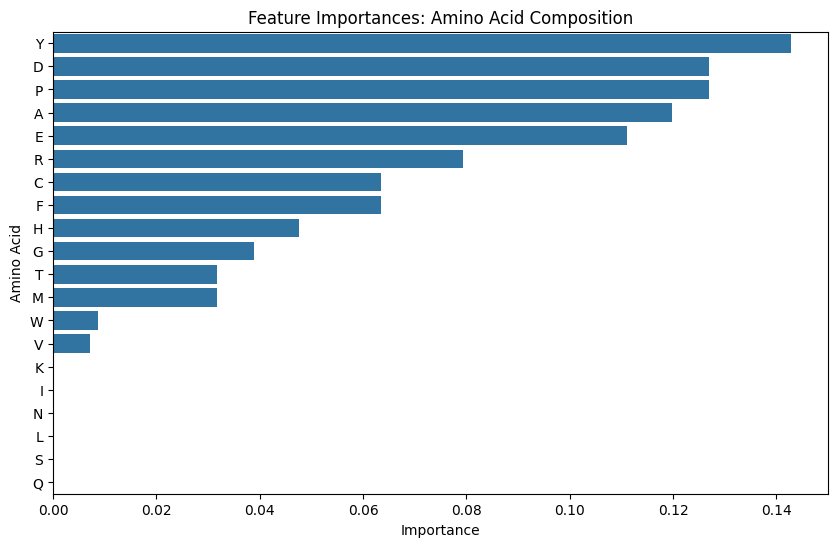

In [11]:
 # Import necessary libraries
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from Bio import PDB
from Bio import SeqIO
from Bio.PDB import Polypeptide
from Bio.PDB import PDBList

pdb_downloader = PDBList()

VALID_AAS = set('ACDEFGHIKLMNPQRSTVWY')
# Hydrophobicity values (Kyte-Doolittle scale)
AA_HYDROPHOBICITY_SCALE = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}
# Molecular weight (approximate, not including modifications)
AA_MOLECULAR_WEIGHT = {
    'A': 89.1, 'C': 121.2, 'D': 133.1, 'E': 147.1, 'F': 165.2,
    'G': 75.1, 'H': 155.2, 'I': 131.2, 'K': 146.2, 'L': 131.2,
    'M': 149.2, 'N': 132.1, 'P': 115.1, 'Q': 146.2, 'R': 174.2,
    'S': 105.1, 'T': 119.1, 'V': 117.1, 'W': 204.2, 'Y': 181.2
}

# Mapping from three-letter to one-letter amino acid codes
THREE_TO_ONE = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
    'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
    'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
    'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}


def compute_aa_composition(seq):
    """Compute amino acid composition vector for a given sequence."""
    counts = {aa: 0 for aa in VALID_AAS}
    for aa in seq:
        if aa in counts:
            counts[aa] += 1
    total = len(seq)
    return np.array([counts[aa] / total for aa in sorted(VALID_AAS)])

def categorize_length(length):
    """Categorize protein chain length."""
    if length < 50:
        return 'short'
    elif length < 150:
        return 'medium'
    else:
        return 'long'

def compute_hydrophobicity(seq):
    scores = [AA_HYDROPHOBICITY_SCALE.get(aa, 0.0) for aa in seq]
    return np.mean(scores) if scores else 0.0

def compute_molecular_weight(seq):
    weights = [AA_MOLECULAR_WEIGHT.get(aa, 0.0) for aa in seq]
    return np.mean(weights) if weights else 0.0

def compute_net_charge(seq):
    positive = sum(seq.count(aa) for aa in 'KRH')
    negative = sum(seq.count(aa) for aa in 'DE')
    return positive - negative


def load_all_fasta_sequences(pdb_ids, data_dir):
    """Load sequences from prepared FASTA files."""
    records = []
    for pdb_id in pdb_ids:
        fasta_path = os.path.join(data_dir, f'{pdb_id}_sequences.fasta')
        if os.path.exists(fasta_path):
            with open(fasta_path, 'r') as f:
                current_id = None
                for line in f:
                    line = line.strip()
                    if line.startswith('>'):
                        current_id = line[1:]  # remove ">"
                    else:
                        records.append({'pdb_chain_id': current_id, 'sequence': line})
        else:
            print(f"Warning: File {fasta_path} not found.")
    return pd.DataFrame(records)


# Main process
# Load data and sequence Metadata
data_dir = os.path.join(os.getcwd(), 'data')
pdb_ids = ['6P8Q', '6H7H', '1N8Z']
df = pd.read_csv(os.path.join(data_dir, 'all_sequences.csv'))
sequences_df = load_all_fasta_sequences(pdb_ids, data_dir)

# Feature Engineering
sequences_df['length'] = sequences_df['sequence'].apply(len)
sequences_df['length_category'] = sequences_df['length'].apply(categorize_length)
composition_features = sequences_df['sequence'].apply(compute_aa_composition)
composition_df = pd.DataFrame(composition_features.tolist(), columns=sorted(VALID_AAS))

modeling_df = pd.concat([sequences_df, composition_df], axis=1)

# Set up a basic modeling task:
# Predict whether chain is "short" (<100) or "long" (>=100)
modeling_df['label'] = (modeling_df['length'] > 100).astype(int)

X = modeling_df[sorted(VALID_AAS)].values
y = modeling_df['label'].values

# Modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# Train a baseline Random Forest model and evaluate performance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['short', 'long']))
#Interpretation
print("\n\nInterpretation:")
print("- At first glance, this model achieved baseline performance using simple amino acid composition features.")
print("- It would appear that certain amino acids contribute more to distinguishing short vs. long chains, possibly reflecting biases in protein design.")
print("- This baseline could possibly serve as a comparison point with the addition of structural or functional features.")
print("-"*30)

# Feature Importances
feature_importances = pd.Series(rf.feature_importances_, index=sorted(VALID_AAS)).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances: Amino Acid Composition')
plt.xlabel('Importance')
plt.ylabel('Amino Acid')
plt.show()





**Results:**  
- The model achieved an accuracy of 75% on the test set.
- Feature importance analysis revealed that certain amino acids (e.g. Tyrosine and Aspartic Acid) are particularly predictive of chain length categories.

**Significance:**  
- While this is a simple task, it validates the feature extraction pipeline and sets a strong baseline.
- Future steps will involve incorporating more sophisticated features (secondary structure, solvent accessibility, etc.) and moving toward **generative modeling** for sequence design.

**Long-term Goal:**
- Integrate additional metadata (e.g., chain type, resolution, source organism).
- Experiment with more complex features (e.g., sequence embeddings, graph-based representations).
- Benchmark different algorithms beyond Random Forest. Develop deep learning models (e.g., LSTM, Transformer) for more complex predictions.
- Define more realistic modeling tasks (e.g., stability prediction, binding prediction).

## Interpretation of Initial Results

The baseline Random Forest model achieved an accuracy of 75% on the (very small) test set. However, a closer look at the classification report reveals that the model performed well only for the "long" chain class, and failed to correctly classify any "short" chains. This indicates a strong class imbalance and suggests that the model is currently overfitting to the majority class.

The top amino acids contributing to model decisions were Y, D, P, A, E, and R. While this might hint at biologically meaningful patterns, the small sample size likely introduces considerable noise. These early findings highlight the need for:

- Larger and more balanced training datasets
- Additional feature engineering beyond simple amino acid composition
- Careful evaluation of model performance across all classes

These improvements will form the basis for future iterations of the modeling pipeline.

## Key Problem with the Current Approach

** The accuracy** of the current model is calculated as 75% of the predictions were correct (for a very small sample set of n=4). 
When looking at the other metrics for performance, **the precision** (of everything predicted as this class, how many were actually correct?) and **the recall** (of everything that was truly this class, how many did we find?), these are calulated as 75% (for long) and 100% (for long), respectively. 

** However, the model completely failed to predict any short sequences** (precision = 0, recall = 0 for short). The model basically defaulting to predicting everything as "long" because that's what dominates the small test set.

### Null Hypothesis Sanity Check
This next function is testing is to establish a baseline assumption of "no effect" or "no relationship" that is then tested against observed data. It provides a framework for determining whether observed results are likely due to random chance or if they suggest a real relationship.

- First, this simple function will shuffle the labels randomly and trains a model, to simulate "no real relationship" between features and labels.
- Next the real model's accuracy compared to that genearted from the null hypothesis - if the real model's is not much better than null, it's not learning real patterns yet.






In [12]:
def evaluate_null_model(X, y, n_runs=10, random_state=42):
    """
    Evaluate model performance when labels are randomly shuffled.
    
    Args:
        X (np.ndarray): Features.
        y (np.ndarray): True labels.
        n_runs (int): How many times to shuffle and evaluate.
        random_state (int): Seed for reproducibility.
        
    Returns:
        List of accuracies across shuffled runs.
    """
    np.random.seed(random_state)
    scores = []
    
    for _ in range(n_runs):
        shuffled_y = np.random.permutation(y)
        X_train, X_test, y_train, y_test = train_test_split(X, shuffled_y, random_state=random_state, stratify=shuffled_y)
        model = RandomForestClassifier(n_estimators=100, random_state=random_state)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        scores.append(acc)
    
    return scores

null_scores = evaluate_null_model(X, y)
print(f"Null Model Mean Accuracy: {np.mean(null_scores):.3f} +/- {np.std(null_scores):.3f}")


Null Model Mean Accuracy: 0.750 +/- 0.000


## Next Steps (02_Expanded_Sequence_Modeling.ipynb)
- Integrate additional metadata (e.g., chain type, resolution, source organism).
- Experiment with more complex features (e.g., sequence embeddings, graph-based representations).

| Current State | What It Means | What To Do |
|:----|:----|:----|
| Real accuracy = Null accuracy | Model isn't learning real signal | Add data + features |
| Only 4 test samples | Cannot trust results | Increase dataset |
| Only composition features | Not rich enough | Add more biological features |

In the first random data generation, the model accuracy for the null hypthoesis is 75% and equal to the model performance generated for the real data. This means **the current model is guessing correctly just by chance** — maybe because most of the PDB ID samples are from the majority class (long chains), and it's just learning to predict "long" every time. 

### Later (03_Developing_Deep_Learning_Models.ipynb)
- Benchmark different algorithms beyond Random Forest. Develop deep learning models (e.g., LSTM, Transformer) for more complex predictions.
- Define more realistic modeling tasks (e.g., stability prediction, binding prediction).